In [ ]:
1from IPython.display import Image, display
display(Image(filename='/content/drive/MyDrive/Deep_Learning_Assignment2/mobilenet_16classifier/images/banner-image.png'))

## Title: 16-class Image Classifier
#### *Vanessa Atta-Fynn* - **22425700**

## Table of Contents
1. [Project Overview](#project-overview)
2. [Setup & Paths](#setup-paths)
3. [Configuration](#configuration)
4. [Data & Augmentation](#data-augmentation)
5. [Model](#model)
6. [Training](#training)
7. [Results & Analysis](#results-analysis)
8. [Prediction & Submission](#prediction-submission)

<a id="project-overview"></a>

### 1. Project Overview

 - This notebook implements an image classification pipeline that categorises images into 16 classes — animals, vehicles, household objects and everyday items.

- The assignment specifies a MobileNet-like CNN architecture under 4 million parameters, trained from scratch on a labelled dataset of roughly 6,400 images. **No pretrained weights are used.**

- MobileNets are CNNs originally designed to run efficiently on small devices. They achieve this by replacing standard convolutions with a two-step cheaper alternative i.e. depthwise then pointwise convolution, which cuts parameter count significantly without much accuracy loss. That efficiency is exactly why it fits the 4M parameter budget here.

- **Role of this notebook:** It orchestrates the full pipeline i.e. data loading, model training, evaluation and generating the submission CSV. The actual logic lives in the .py modules (model.py, data.py, train.py etc.). This notebook calls them in order and shows what's happening at each step.

<a id="setup-paths"></a>

### 2. Setup & Paths

In this section, the following was done:
1. Mount Google Drive
2. Set the path
3. Check GPU is available

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, sys

PROJECT_DIR = '/content/drive/MyDrive/Deep_Learning_Assignment2/mobilenet_16classifier'
DATA_ROOT   = '/content/drive/MyDrive/Deep_Learning_Assignment2/Assignment2_datasets'

TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

sys.path.insert(0, PROJECT_DIR)

assert os.path.isdir(TRAIN_DIR), f"TRAIN_DIR not found: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR),  f"TEST_DIR not found: {TEST_DIR}"
print("Train dir:", TRAIN_DIR)
print("Test  dir:", TEST_DIR)

Train dir: /content/drive/MyDrive/Deep_Learning_Assignment2/Assignment2_datasets/train
Test  dir: /content/drive/MyDrive/Deep_Learning_Assignment2/Assignment2_datasets/test


In [3]:
import torch
from utils import get_device

device = get_device()
print("Device:", device)

Device: cpu


<a id="configuration"></a>

### 3. Configuration
All hyperparameters live in config.py. We load the defaults here and override what needs changing for our setup i.e. image size, batch size, epochs and so on.

In [4]:
import shutil
from config import Config, CLASS_NAMES, NUM_CLASSES

cfg = Config()

# Paths
cfg.train_dir  = TRAIN_DIR
cfg.test_dir   = TEST_DIR
cfg.output_dir = os.path.join(PROJECT_DIR, 'outputs')
os.makedirs(cfg.output_dir, exist_ok=True)

# Image & training settings
cfg.img_size    = 128
cfg.batch_size  = 128
cfg.epochs      = 150
cfg.num_workers = 2

print(f"Classes ({NUM_CLASSES}):", CLASS_NAMES)
print(f"Image size: {cfg.img_size} | Batch: {cfg.batch_size} | Epochs: {cfg.epochs}")

Classes (16): ['airplane', 'bear', 'bicycle', 'bird', 'boat', 'bottle', 'car', 'cat', 'chair', 'clock', 'dog', 'elephant', 'keyboard', 'knife', 'oven', 'truck']
Image size: 128 | Batch: 128 | Epochs: 150


In [5]:
# Copy dataset from Drive to local Colab disk which is much faster I/O during training.
LOCAL_DATA = '/content/data'

train_local = os.path.join(LOCAL_DATA, 'train')
test_local  = os.path.join(LOCAL_DATA, 'test')

# FIX: Check if the base destination folder already exists
if not os.path.exists(LOCAL_DATA):
    print('Copying dataset to local disk...')
    shutil.copytree(DATA_ROOT, LOCAL_DATA)
    print('Done.')
else:
    # If the folder exists but is empty (which caused your error), fill it safely
    if not os.path.isdir(train_local):
        print('Local folder exists but is empty. Copying dataset...')
        shutil.copytree(DATA_ROOT, LOCAL_DATA, dirs_exist_ok=True)
        print('Done.')
    else:
        print('Local data already exists, skipping copy.')

cfg.train_dir = train_local
cfg.test_dir  = test_local
print('Train:', cfg.train_dir)
print('Test: ', cfg.test_dir)


Copying dataset to local disk...
Done.
Train: /content/data/train
Test:  /content/data/test


<a id="data-augmentation"></a>

### 4. Data & Augmentation

We have 6,400 labelled training images across 16 classes which about 400 per class. That's a small dataset for training from scratch, so augmentation is critical. Here we show the model many slightly different versions of each image so it learns the object itself, not the specific photo.

The augmentations applied during training:
- RandomResizedCrop - randomly crops and resizes, forcing the model to recognise objects at different scales and positions
- RandomHorizontalFlip - mirrors the image left-right, doubles effective variety
- RandomRotation - slight tilts up to 15degrees, handles objects that aren't perfectly upright
- ColorJitter - randomly shifts brightness, contrast, saturation and hue, so colour alone isn't a cheat code
- RandomErasing - blanks out a random patch, simulates occlusion (object partially hidden)
- Mixup / CutMix - at batch level, blends two images together or pastes a patch from one into another. Strong regulariser on small datasets.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from data import build_datasets

train_set, val_set, _, _ = build_datasets(cfg)
print(f"Train: {len(train_set)} images | Val: {len(val_set)} images")

Train: 5760 images | Val: 640 images


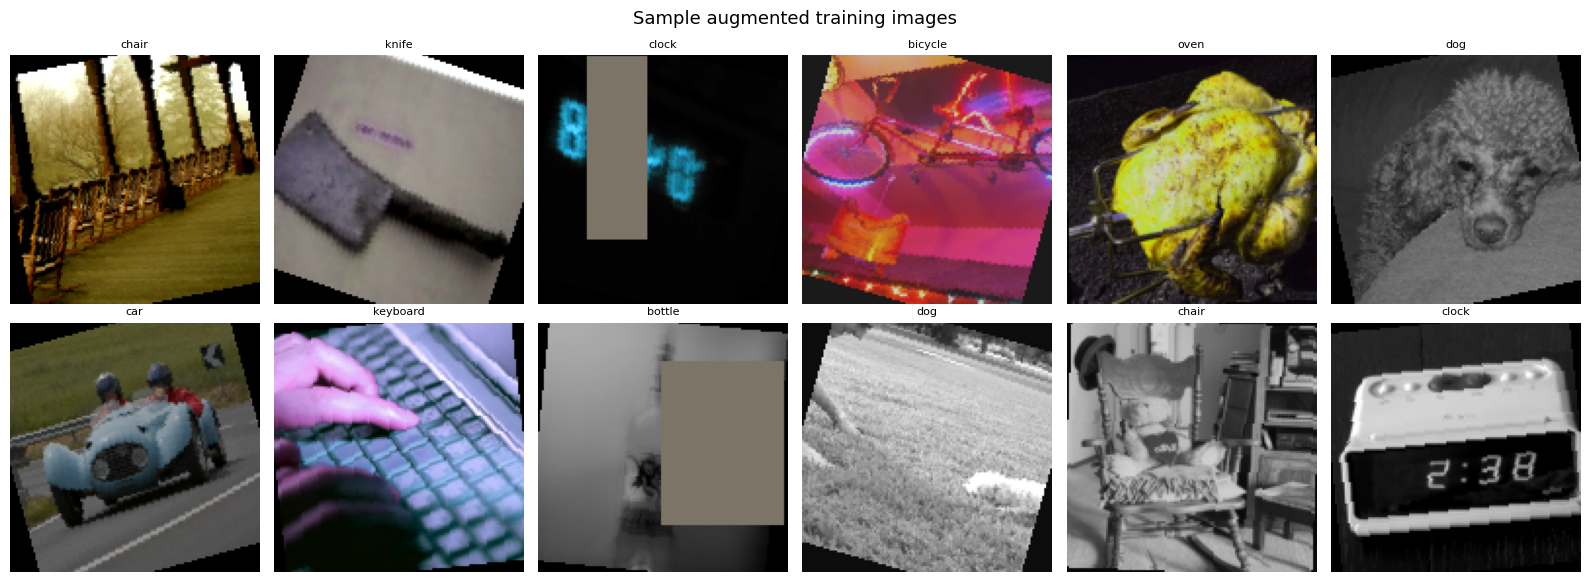

In [7]:
# Visualise a sample of augmented training images.
# Each time you run this cell you'll see different augmented versions.
mean = np.array(cfg.mean)
std  = np.array(cfg.std)

def denorm(t):
    img = t.permute(1, 2, 0).numpy() * std + mean
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Sample augmented training images", fontsize=13)
for ax in axes.ravel():
    img, label = train_set[np.random.randint(len(train_set))]
    ax.imshow(denorm(img))
    ax.set_title(CLASS_NAMES[label], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observation:**
The grey patches are RandomErasing in action i.e. randomly blanking out a region to simulate occlusion. Some images also show noticeable colour shifts, images titled at an angle and tight crops that cut off parts of the object. The augmentation is intentionally aggressive given the small dataset size so the model is forced to generalise rather than memorise.

<a id="model"></a>

### 5. Model
The architecture is a custom CNN built entirely from scratch, inspired by MobileNetV2 but with three key modifications. The core idea stays the same — depthwise separable convolutions replace standard convolutions, keeping the parameter count low while maintaining a deep network.

Each block does four things now:
- Expand - a 1x1 conv increases channels, giving the network more room to process
-  Depthwise 3x3 conv - filters each channel independently, cheap but effective
- Squeeze-and-Excitation - learns to reweight channels based on what matters for the current image. Some channels detect edges, some detect colours - SE lets the network decide which to trust more for each input
- Project - a 1x1 conv squishes channels back down, no activation (keeps information intact)

A skip connection adds the input directly to the output when shapes match.
Three differences from standard MobileNetV2:

1. SE blocks added after every depthwise conv - channel attention mechanism
2. Hardswish activation instead of ReLU6 - smoother, works better in practice
3. Two-layer classifier head - instead of going straight to 16 classes, an intermediate layer of 256 units gives the classifier more expressive power

In [8]:
from model import build_model, count_parameters

model = build_model(
    num_classes=NUM_CLASSES,
    width_mult=cfg.width_mult,
    dropout=cfg.dropout
).to(device)

n_params = count_parameters(model)
print(f"Total trainable parameters: {n_params:,} ({n_params/1e6:.2f}M)")
assert n_params < 4_000_000, "Over the 4M parameter budget!"
print("Parameter budget: OK")

Total trainable parameters: 3,127,534 (3.13M)
Parameter budget: OK


In [9]:
# Running model on dummy batch and confirm the output shape is (batch_size, 16)

dummy = torch.randn(4, 3, cfg.img_size, cfg.img_size).to(device)
with torch.no_grad():
    out = model(dummy)
print(f"Input shape:  {list(dummy.shape)}")
print(f"Output shape: {list(out.shape)}  (expected [4, 16])")

Input shape:  [4, 3, 128, 128]
Output shape: [4, 16]  (expected [4, 16])


<a id="training"></a>

### 6. Training

We train using SGD with Nesterov momentum and a cosine annealing warm restarts schedule. The learning rate starts low, ramps up linearly over 5 warmup epochs, then follows a cosine curve down to near zero, then restarts. The restarts help the model escape flat regions and keep improving.

Label smoothing is applied to the loss function so instead of telling the model "this is 100% a cat", we say "this is 90% a cat, 10% something else". This stops the model from being overconfident and generalises better.

EMA (Exponential Moving Average) keeps a smoothed copy of the weights throughout training. We evaluate both the raw model and the EMA model each epoch and keep whichever performs better. Early on the raw model usually wins; later the EMA copy tends to take over.

In [10]:
from train import run_training

history, best_ckpt = run_training(cfg)

Device: cpu | classes: 16
Train images: 5760 | Val images: 640
Model parameters: 3,127,534 (3.13M)
Epoch   1/150 | lr 0.0125 | train loss 2.769 acc 0.073 | val loss 2.773 acc 0.062 (ema) | 379.1s
  -> saved new best (val acc 0.062) to /content/drive/MyDrive/Deep_Learning_Assignment2/mobilenet_16classifier/outputs/best_model.pth
Epoch   2/150 | lr 0.0188 | train loss 2.748 acc 0.087 | val loss 2.705 acc 0.105 (raw) | 380.5s
  -> saved new best (val acc 0.105) to /content/drive/MyDrive/Deep_Learning_Assignment2/mobilenet_16classifier/outputs/best_model.pth


KeyboardInterrupt: 

In [ ]:
# Plot training curves
import matplotlib.pyplot as plt

epochs    = [h['epoch'] for h in history]
train_acc = [h['train_acc'] for h in history]
val_acc   = [h['val_acc'] for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss   = [h['val_loss'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_acc, label='Train accuracy')
ax1.plot(epochs, val_acc,   label='Val accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy over training')
ax1.legend()

ax2.plot(epochs, train_loss, label='Train loss')
ax2.plot(epochs, val_loss,   label='Val loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss over training')
ax2.legend()

plt.tight_layout()
plt.show()

**Observation:**
Val accuracy sits consistently above train accuracy throughout which is a sign that the augmentation is working as intended, making training harder than evaluation. The zigzag pattern reflects the cosine warm restarts: each learning rate reset causes a brief dip before pushing accuracy higher. Both curves are still climbing at epoch 90, which motivated extending training to 150 epochs in this version

<a id="results-analysis"></a>

### 7. Results & Analysis
Training done. Now we look at WHERE the model is doing well and where it's struggling — overall accuracy is one number, but the confusion matrix and per-class breakdown tell the real story

In [ ]:
from visualize import plot_confusion_matrix, plot_per_class_accuracy, get_predictions
from data import build_datasets
from torch.utils.data import DataLoader
import torch

# Load best checkpoint
ckpt = torch.load(best_ckpt, map_location=device)
print(f"Best checkpoint | val accuracy: {ckpt['val_acc']:.3f}")

# Rebuild validation set
_, val_set, _, _ = build_datasets(cfg)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=cfg.num_workers)

# Get predictions
from visualize import get_predictions
from config import CLASS_NAMES, NUM_CLASSES
from model import build_model

eval_model = build_model(NUM_CLASSES, ckpt.get('width_mult', 1.0), dropout=0.0).to(device)
eval_model.load_state_dict(ckpt['model_state'])

targets, preds = get_predictions(eval_model, val_loader, device)
overall = (targets == preds).mean()
print(f"Overall validation accuracy: {overall:.1%}")

In [ ]:
# Confusion matrix
plot_confusion_matrix(targets, preds, CLASS_NAMES, save_path=os.path.join(cfg.output_dir, 'confusion_matrix.png'))

In [ ]:
# Per-class accuracy
plot_per_class_accuracy(targets, preds, CLASS_NAMES, save_path=os.path.join(cfg.output_dir, 'per_class_accuracy.png'))

<a id="prediction-submission"></a>

### 8. Prediction & Submission
Model is trained and evaluated. Now we run it on the 1600 unlabelled test images and generate the submission CSV. We use test-time augmentation (TTA) i.e. each image is evaluated twice, once normally and once flipped horizontally, and the predictions are averaged. Small but consistent accuracy boost.

In [ ]:
from predict import run_inference

submission_path = os.path.join(cfg.output_dir, 'submission.csv')

run_inference(
    best_ckpt,
    cfg.test_dir,
    submission_path,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    use_tta=True
)

In [ ]:
# Check on the submission file before uploading
import pandas as pd

df = pd.read_csv(submission_path)
print(f"Total predictions: {len(df)} (expected 1600)")
print(f"All labels valid: {set(df['Prediction']).issubset(set(CLASS_NAMES))}")
df.head()

In [ ]:
# Download submission.csv directly from Colab
try:
    from google.colab import files
    files.download(submission_path)
except Exception:
    print(f"Submission saved at: {submission_path}")

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/drive/MyDrive/Deep_Learning_Assignment2/mobilenet_16classifier/images/footer-image.png'))